In [48]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic

In [49]:
from src.cleaning_and_helpers import plot_test_preds

Import X and y from data prep steps

In [50]:
X = np.load('../pollenGeolocation_saved/X.npy')
y = np.load('../pollenGeolocation_saved/y.npy')

In [51]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# Create scaler for X and y
sc_X = StandardScaler()
sc_y = StandardScaler()

# Scale training data
X_train = sc_X.fit_transform(X_train)
y_train = sc_y.fit_transform(y_train)  

# Scale test data using training parameters
X_test = sc_X.transform(X_test)
y_test = sc_y.transform(y_test)  

# Linear regression  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.MultiTaskLasso.html

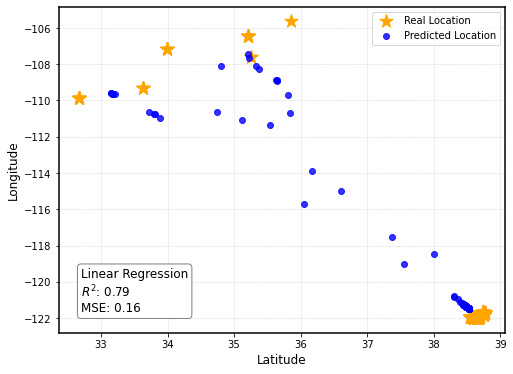

In [52]:
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

MTKNReg = linear_model.MultiTaskLasso(alpha=0.1)
MTKNReg.fit(X_train, y_train)
preds_LR = MTKNReg.predict(X_test)


LR_rsq = r2_score(y_test,preds_LR)
LR_mse = mean_squared_error(y_test,preds_LR)
distances_LR = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_LR)]
avg_distance_LR = np.mean(distances_LR)
se_distance_LR = np.std(distances_LR) 


plot_test_preds(y_test, preds_LR, sc_y, "Linear Regression",ax=ax)

# SVR Support Vector Regression multioutput regressor
https://medium.com/pursuitnotes/support-vector-regression-in-6-steps-with-python-c4569acd062d  
https://scikit-learn.org/stable/modules/svm.html#regression
https://datascience.stackexchange.com/questions/82743/valueerror-y-should-be-a-1d-array-got-an-array-of-shape-285-30-instead  
https://www.section.io/engineering-education/support-vector-regression-in-python/

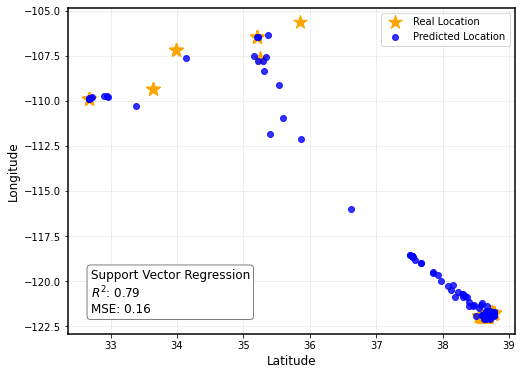

In [53]:
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the SVR regressor
svr = SVR(epsilon=0.01)

# Create the Multioutput Regressor
mor = MultiOutputRegressor(svr)

# Train the regressor
mor = mor.fit(X_train, y_train)

# Generate predictions for testing data
preds_SVR = mor.predict(X_test)

SVR_rsq = r2_score(y_test,preds_SVR)
SVR_mse = mean_squared_error(y_test,preds_SVR)
distances_SVR = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_SVR)]
avg_distance_SVR = np.mean(distances_SVR)
se_distance_SVR = np.std(distances_SVR) 

plot_test_preds(y_test, preds_SVR, sc_y, "Support Vector Regression", ax=ax)

# k-Nearest Neighbors for Multioutput Regression
https://machinelearningmastery.com/multi-output-regression-models-with-python/

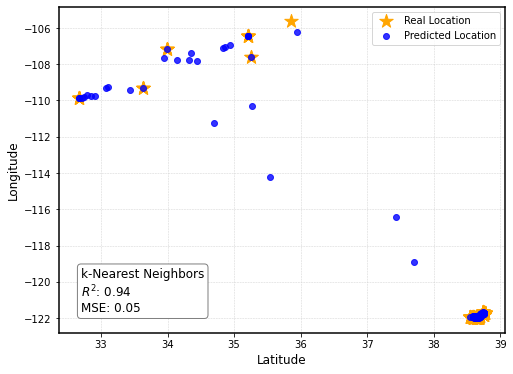

In [54]:
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# fit model
KNR = KNeighborsRegressor(algorithm='auto', weights='distance') #slightly better when weighted by distance
KNR = KNR.fit(X_train, y_train)

preds_KNR = KNR.predict(X_test)

KNR_rsq = r2_score(y_test,preds_KNR)
KNR_mse = mean_squared_error(y_test,preds_KNR)
distances_KNR = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_KNR)]
avg_distance_KNR = np.mean(distances_KNR)
se_distance_KNR = np.std(distances_KNR) 

plot_test_preds(y_test, preds_KNR, sc_y, "k-Nearest Neighbors", ax=ax)

# Decision Tree for multioutput regression  


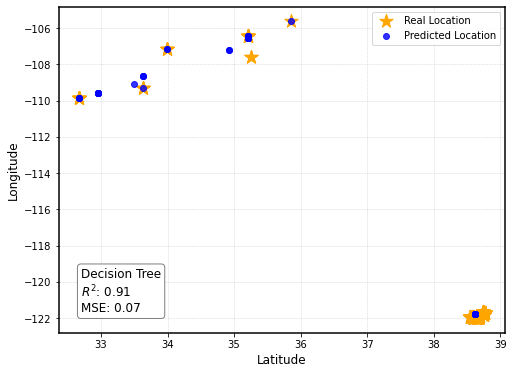

In [55]:
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# fit model
DTR = DecisionTreeRegressor(max_depth=5)
DTR = DTR.fit(X_train, y_train)

preds_DTR = DTR.predict(X_test)

DTR_rsq = r2_score(y_test,preds_DTR)
DTR_mse = mean_squared_error(y_test,preds_DTR)
distances_DTR = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_DTR)]
avg_distance_DTR = np.mean(distances_DTR)
se_distance_DTR = np.std(distances_DTR) 


plot_test_preds(y_test, preds_DTR, sc_y, "Decision Tree", ax=ax)

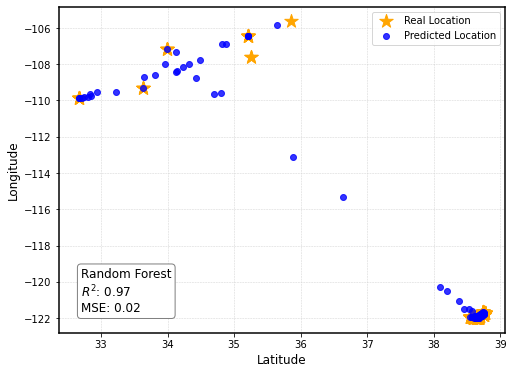

In [56]:
#Random forest
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# Using tuned model
rf =RandomForestRegressor(n_estimators = 400,
                          min_samples_split = 2, 
                          min_samples_leaf = 1, 
                          max_features = 'sqrt', 
                          max_depth = None, 
                          bootstrap = False) 
rf = rf.fit(X_train,y_train)

pred_train = rf.predict(X_train)
preds_RF = rf.predict(X_test)

RF_rsq = r2_score(y_test,preds_RF)
RF_mse = mean_squared_error(y_test,preds_RF)
distances_RF = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_RF)]
avg_distance_RF = np.mean(distances_RF)
se_distance_RF = np.std(distances_RF) 

plot_test_preds(y_test, preds_RF, sc_y, "Random Forest", ax=ax)

https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

In [57]:
RF_tuning = False
if RF_tuning == True:
    from sklearn.model_selection import RandomizedSearchCV
    # Number of trees in random forest
    n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
    # Number of features to consider at every split
    max_features = ['auto', 'sqrt']
    # Maximum number of levels in tree
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    # Minimum number of samples required to split a node
    min_samples_split = [2, 5, 10]
    # Minimum number of samples required at each leaf node
    min_samples_leaf = [1, 2, 4]
    # Method of selecting samples for training each tree
    bootstrap = [True, False]
    # Create the random grid
    random_grid = {'n_estimators': n_estimators,
                'max_features': max_features,
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'bootstrap': bootstrap}
    print(random_grid)

    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)
    # Fit the random search model
    rf_random.fit(X_train, y_train)

    rf_random.best_params_



XGBoost

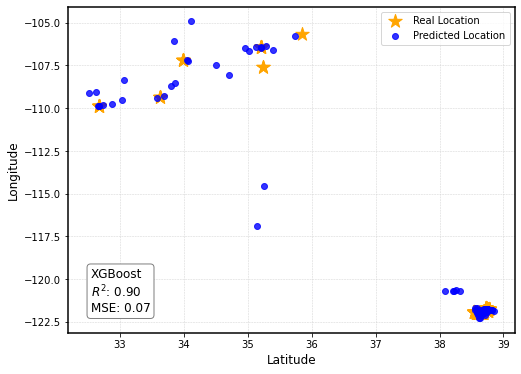

In [58]:
from xgboost import XGBRegressor

# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the base XGBoost regressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Wrap with MultiOutputRegressor for multioutput regression
multi_xgb = MultiOutputRegressor(xgb)

# Train the model
multi_xgb.fit(X_train, y_train)

# Generate predictions
preds_xg = multi_xgb.predict(X_test)

XG_rsq = r2_score(y_test,preds_xg)
XG_mse = mean_squared_error(y_test,preds_xg)

plot_test_preds(y_test, preds_xg, sc_y, "XGBoost", ax=ax)


In [59]:
tune_XG = True

if tune_XG == True:
    # hyperparam tuning for xgboost
    # Example hyperparameter grid for XGBRegressor
    param_grid = {
        'estimator__n_estimators': [50, 100, 200],
        'estimator__max_depth': [3, 5, 7],
        'estimator__learning_rate': [0.01, 0.1, 0.2],
        'estimator__subsample': [0.8, 1.0],
        'estimator__colsample_bytree': [0.8, 1.0],
        'estimator__reg_alpha': [0, 0.1, 1],  # L1 regularization
        'estimator__reg_lambda': [0.1, 1, 10],  # L2 regularization
    }
    # Set up RandomizedSearchCV
    xgb_random = RandomizedSearchCV(
        estimator=multi_xgb,
        param_distributions=param_grid,
        n_iter=100,  # Number of parameter settings sampled
        cv=3,        # 3-fold cross-validation
        verbose=2,
        random_state=42,
        n_jobs=-1    # Use all available cores
    )
    # Fit the RandomizedSearchCV
    xgb_random.fit(X_train, y_train)

    # Get the best parameters
    print("Best parameters found: ", xgb_random.best_params_)


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters found:  {'estimator__subsample': 0.8, 'estimator__reg_lambda': 10, 'estimator__reg_alpha': 0, 'estimator__n_estimators': 200, 'estimator__max_depth': 7, 'estimator__learning_rate': 0.1, 'estimator__colsample_bytree': 0.8}


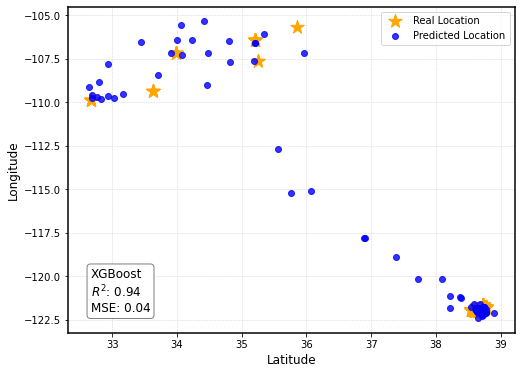

In [62]:
# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 6))

# Get predictions using the best estimator
best_xgb = xgb_random.best_estimator_
preds_XG_best = best_xgb.predict(X_test)

XG_rsq_best = r2_score(y_test,preds_XG_best)
XG_mse_best = mean_squared_error(y_test,preds_XG_best)
distances_XG = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds_XG_best)]
avg_distance_XG = np.mean(distances_XG)
se_distance_XG = np.std(distances_XG) 

plot_test_preds(y_test, preds_XG_best, sc_y, "XGBoost", ax=ax)


In [65]:
method = ['Linear Regression', 
          'SVR Support Vector Regression' , 
          'Decision Tree', 
          'k-Nearest Neighbors', 
          'XGBoost', 
          'Random Forest'
          ]
rsquared = [LR_rsq, 
            SVR_rsq, 
            DTR_rsq,
            KNR_rsq, 
            XG_rsq_best,
            RF_rsq]
MSE = [LR_mse, 
       SVR_mse, 
       DTR_mse,
       KNR_mse, 
       XG_mse_best,
       RF_mse]
dist = [avg_distance_LR,
        avg_distance_SVR,
        avg_distance_DTR,
        avg_distance_KNR,
        avg_distance_XG,
        avg_distance_RF]

se = [se_distance_LR,
      se_distance_SVR,
      se_distance_DTR,
      se_distance_KNR,
      se_distance_XG,
      se_distance_RF]

df = pd.DataFrame({'Model' : method,
              'r2' : rsquared,
              'MSE' : MSE
              })
df

df.to_csv("tables/model_results.csv")

In [105]:
import seaborn as sns
df

,model,distance_loss
0,Linear Regression,21.102957
1,Linear Regression,18.789174
2,Linear Regression,13.381455
3,Linear Regression,10.807595
4,Linear Regression,18.789174
...,...,...
1657,Random Forest,1.784600
1658,Random Forest,2.520948
1659,Random Forest,4.121147
1660,Random Forest,1.511295


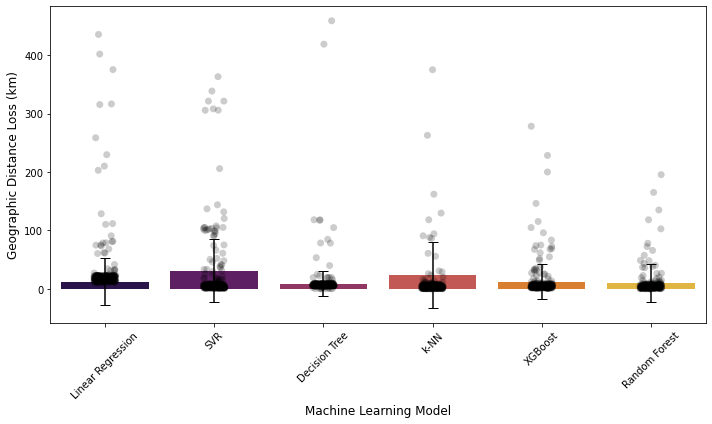

In [106]:

# Combine data into a DataFrame
data = {
    "model": ["Linear Regression"] * len(distances_LR) +
             ["SVR"] * len(distances_SVR) +
             ["Decision Tree"] * len(distances_DTR) +
             ["k-NN"] * len(distances_KNR) +
             ["XGBoost"] * len(distances_XG) +
             ["Random Forest"] * len(distances_RF),
    "distance_loss": distances_LR + distances_SVR + distances_DTR + distances_KNR + distances_XG +
                     distances_RF,
    "distance_std": se_distance_LR + se_distance_SVR + se_distance_DTR + se_distance_KNR + se_distance_XG + se_distance_RF
}

df = pd.DataFrame(data)


# Combine data into a DataFrame
data = {
    "model": ["Linear Regression"] * len(distances_LR) +
             ["SVR"] * len(distances_SVR) +
             ["Decision Tree"] * len(distances_DTR) +
             ["k-NN"] * len(distances_KNR) +
             ["XGBoost"] * len(distances_XG) +
             ["Random Forest"] * len(distances_RF),
    "distance_loss": distances_LR + distances_SVR + distances_DTR + distances_KNR + distances_XG +
                     distances_RF,
}

df = pd.DataFrame(data)

# Compute means and standard deviations
summary_stats = df.groupby("model")["distance_loss"].agg(mean="mean", std="std").reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_stats, x="model", y="mean", palette="inferno", ci=None)

# Add custom error bars for standard deviation
plt.errorbar(
    x=range(len(summary_stats)),  # X-coordinates of bars
    y=summary_stats["mean"],  # Mean values
    yerr=summary_stats["std"],  # Standard deviations
    fmt="none",  # No markers for the error bars
    c="black",  # Color of error bars
    capsize=5,  # Length of the caps on the error bars
)

# Overlay individual data points for clarity
sns.stripplot(data=df, x="model", y="distance_loss", color="black", size=7, jitter=True, alpha=0.2)


# Add labels and title
plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("Geographic Distance Loss (km)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [119]:
df_LR = pd.DataFrame(df.distance_loss[df.model == 'Linear Regression'])
df_SVR = pd.DataFrame(df.distance_loss[df.model == 'SVR'])
df_DT = pd.DataFrame(df.distance_loss[df.model == 'Decision Tree'])
df_KNN = pd.DataFrame(df.distance_loss[df.model == 'k-NN'])
df_XG = pd.DataFrame(df.distance_loss[df.model == 'XGBoost'])
df_RF = pd.DataFrame(df.distance_loss[df.model == 'Random Forest'])

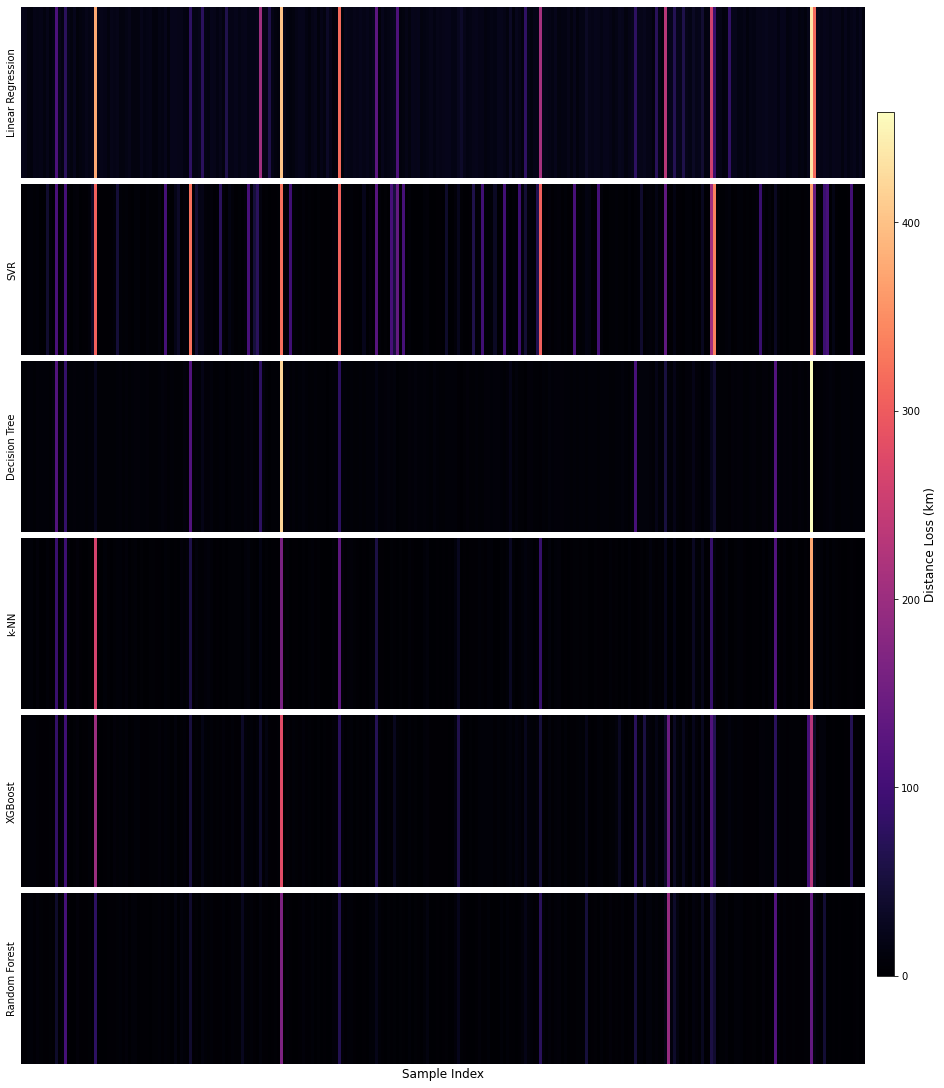

In [138]:
# Normalize color scale across all heatmaps
vmin = min([df.min().min() for _, df in models])
vmax = max([df.max().max() for _, df in models])

# Create the figure and axes
fig, axes = plt.subplots(len(models), 1, figsize=(12, 15), sharex=True, constrained_layout=True)

# Create a shared colorbar axis
cbar_ax = fig.add_axes([1.01, 0.1, 0.02, 0.8])  # Adjust position and size of the colorbar

# Loop through models and plot each heatmap
for ax, (model_name, data) in zip(axes, models):
    sns.heatmap(data.T, ax=ax, cmap="magma", cbar=False, vmin=vmin, vmax=vmax, xticklabels=False, yticklabels=False)
    ax.set_ylabel(model_name, fontsize=10)

# Add the shared colorbar
sm = plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Distance Loss (km)', fontsize=12)

# Add a common X-axis label
axes[-1].set_xlabel("Sample Index", fontsize=12)

plt.show()

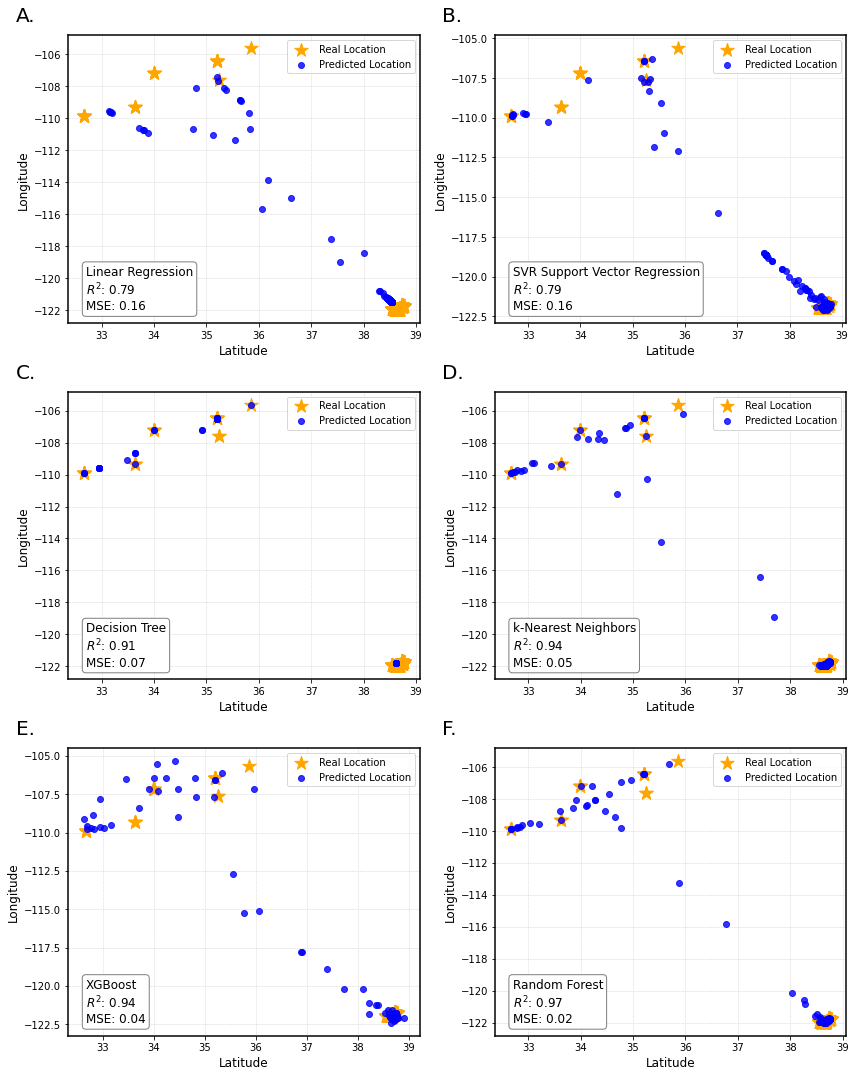

In [ ]:
# plot real vs predicted scatterplots for each model 

method_dict = {'Linear Regression':preds_LR, 
          'SVR Support Vector Regression':preds_SVR ,  
          'Decision Tree':preds_DTR, 
          'k-Nearest Neighbors':preds_KNR, 
          'XGBoost':preds_XG_best,
          'Random Forest':preds_RF}

scaler = sc_y

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 rows, 2 columns
axes = axes.flatten()  # Flatten the 2D array for easy iteration

# Iterate over method_dict to access both model_type and associated preds
for i, (model_type, preds) in enumerate(method_dict.items()):
    ax = axes[i]  # Get the subplot axis
    plot_test_preds(y_test, preds, sc_y, model_type, ax=ax)  # Call the plot function

    # Add panel label in the upper left corner
    ax.text(
        -0.15, 1.1,  # Coordinates in axis-relative units (-0.1 from left, 1.1 above top)
        f"{ascii_uppercase[i]}.",  # Label: A., B., C., ...
        transform=ax.transAxes,  # Use axis-relative coordinates
        fontsize=20,  # Font size
        va='top',  # Vertical alignment
        ha='left'  # Horizontal alignment
    )


# Adjust layout for better spacing
plt.tight_layout()

# Save the plot as a PDF (make sure to do this after plt.show() or tight_layout)
plt.savefig("../pollenGeolocation_saved/figs/real_vs_pred_scatterplots.pdf", format="pdf")

plt.show()

In [ ]:
# TODO plot the distance between real and predicted values for all models together 
# envisioning a boxplot or violin plot with distance bt real and preds as the y and on the x would be
# each model with its own violin

In [ ]:
# TODO add random forest map plot with arrows connecting predicted to real 